In [50]:
import collections
from random import shuffle

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchtext
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
import datasets
import tqdm

In [3]:
seed = 1234

np.random.seed(seed)
torch.manual_seed(seed)
# torch.cuda.manual_seed(seed)
# torch.backends.cudnn.deterministic = True

In [8]:
train_data, test_data = datasets.load_dataset('imdb', split=['train', 'test'])

In [5]:
tokenizer = get_tokenizer('basic_english')

In [6]:
def tokenize_example(example, tokenizer, max_length):
    tokens = tokenizer(example['text'])[:max_length]
    return {'tokens': tokens}

In [9]:
max_length = 256

train_data = train_data.map(tokenize_example, fn_kwargs={'tokenizer': tokenizer, 'max_length': max_length})
test_data = test_data.map(tokenize_example, fn_kwargs={'tokenizer': tokenizer, 'max_length': max_length})

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

In [10]:
test_size = 0.25

train_valid_data = train_data.train_test_split(test_size=test_size)
train_data = train_valid_data['train']
valid_data = train_valid_data['test']

In [13]:
min_freq = 5
special_tokens = ['<unk>', '<pad>']

vocab = build_vocab_from_iterator(train_data['tokens'], min_freq=min_freq, specials=special_tokens)

In [14]:
len(vocab)

21635

In [15]:
unk_index = vocab['<unk>']
pad_index = vocab['<pad>']

In [16]:
pad_index

1

In [17]:
vocab.set_default_index(unk_index)

In [18]:
def numericalize_example(example, vocab):
    ids = vocab.lookup_indices(example['tokens'])
    return {'ids': ids}

In [19]:
train_data = train_data.map(numericalize_example, fn_kwargs={'vocab': vocab})
valid_data = valid_data.map(numericalize_example, fn_kwargs={'vocab': vocab})
test_data = test_data.map(numericalize_example, fn_kwargs={'vocab': vocab})

Map:   0%|          | 0/18750 [00:00<?, ? examples/s]

Map:   0%|          | 0/6250 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

In [20]:
train_data = train_data.with_format(type='torch', columns=['ids', 'label'])
valid_data = valid_data.with_format(type='torch', columns=['ids', 'label'])
test_data = test_data.with_format(type='torch', columns=['ids', 'label'])

In [22]:
train_data[0]

{'label': tensor(1),
 'ids': tensor([  180,     4,    14,    10,   191,   841,    34,     7,     2,   121,
            98,   816,    50,     8,  1516,     2,   380,     7,     2,   184,
             3,     8,   805,    14,    18,    10,     8,   805,  2246,   429,
             3,    12,   347,    15,     2,   388,  1025,     9,    16,    76,
             5,    64,     7, 11198,     3,     2,  9212,    17,   761,     4,
          7812,  5460,   198,    37,     4,     6,  3653,  3683,    17,   226,
             5, 11893,     3,    53,     7,    15,  3310,   354,     5,   689,
             4,     0,  5471,     3,  2706,  3826,     9,    16,   246,    13,
            14,    18,  1111,    33,    17,   126,   188,     8,    35,   597,
           181,    19,     5,    34,  3942,  1381,    13,     2,  5370,     3,
            32,  4228,    10,    41,  2825,     8,    37,     3,     2,  4411,
          1141,   213,  2655,     6, 16946,  3729,   590,  4845,     8,  2416,
             6,  1953,  

In [24]:
def get_collate_fn(pad_index):
    def collate_fn(batch):
        batch_ids = [i['ids'] for i in batch]
        batch_ids = nn.utils.rnn.pad_sequence(batch_ids, batch_first=True, padding_value=pad_index)
        batch_label = [i['label'] for i in batch]
        batch_label = torch.stack(batch_label)
        return {'ids': batch_ids, 'label': batch_label}
    return collate_fn

In [25]:
def get_data_loader(dataset, batch_size, pad_index, shuffle=False):
    collate_fn = get_collate_fn(pad_index)
    data_loader = torch.utils.data.DataLoader(dataset, batch_size, shuffle=shuffle, collate_fn=collate_fn)
    return data_loader

In [26]:
batch_size = 512

train_data_loader = get_data_loader(train_data, batch_size, pad_index=pad_index, shuffle=True)
valid_data_loader = get_data_loader(valid_data, batch_size, pad_index=pad_index)
test_data_loader = get_data_loader(test_data, batch_size, pad_index=pad_index)

In [74]:
class CNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, n_filters, filter_sizes, output_dim, dropout_rate, pad_index):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_index)
        self.convs = nn.ModuleList(
            [nn.Conv1d(embedding_dim, n_filters, filter_size) for filter_size in filter_sizes]
        )
        self.fc = nn.Linear(len(filter_sizes) * n_filters, output_dim)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, ids):
        embedded = self.dropout(self.embedding(ids))
        embedded = embedded.permute(0, 2, 1)
        conved = [torch.relu(conv(embedded)) for conv in self.convs]
        poold = [conv.max(dim=-1).values for conv in conved]
        cat = self.dropout(torch.cat(poold, dim=-1))
        prediction = self.fc(cat)
        return prediction

In [75]:
vocab_size = len(vocab)
embedding_dim = 300
n_filters = 100
filter_sizes = [3, 5, 7]
output_dim = len(train_data.unique('label'))
dropout_rate = 0.5

model = CNN(vocab_size, embedding_dim, n_filters, filter_sizes, output_dim, dropout_rate, pad_index)

In [76]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'This model has {count_parameters(model):,} trainable parameters')

This model has 6,941,402 trainable parameters


In [77]:
# 手动计算参数量
(vocab_size * embedding_dim +
 embedding_dim * n_filters * 3 + n_filters + embedding_dim * n_filters * 5 + n_filters + embedding_dim * n_filters * 7 + n_filters +
 len(filter_sizes) * n_filters * output_dim + output_dim)

6941402

In [78]:
def initialize_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        nn.init.zeros_(m.bias)
    elif isinstance(m, nn.Conv1d):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        nn.init.zeros_(m.bias)

In [79]:
model.apply(initialize_weights)

CNN(
  (embedding): Embedding(21635, 300, padding_idx=1)
  (convs): ModuleList(
    (0): Conv1d(300, 100, kernel_size=(3,), stride=(1,))
    (1): Conv1d(300, 100, kernel_size=(5,), stride=(1,))
    (2): Conv1d(300, 100, kernel_size=(7,), stride=(1,))
  )
  (fc): Linear(in_features=300, out_features=2, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

In [80]:
vectors = torchtext.vocab.GloVe()

In [81]:
pretrained_embedding = vectors.get_vecs_by_tokens(vocab.get_itos())

In [82]:
pretrained_embedding.shape

torch.Size([21635, 300])

In [83]:
model.embedding.weight.data = pretrained_embedding

In [84]:
optimizer = optim.Adam(model.parameters())

In [85]:
criterion = nn.CrossEntropyLoss()

In [86]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [87]:
model = model.to(device)
criterion = criterion.to(device)

In [88]:
def train(dataloader, model, optimizer, criterion, device):
    model.train()
    epoch_loss = []
    epoch_acc = []
    for batch in tqdm.tqdm(dataloader, desc='training...'):
        ids = batch['ids'].to(device)
        label = batch['label'].to(device)
        prediction = model(ids)
        loss = criterion(prediction, label)
        accuracy = get_accuracy(prediction, label)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss.append(loss.item())
        epoch_acc.append(accuracy.item())
    return np.mean(epoch_loss), np.mean(epoch_acc)

In [89]:
def evaluate(dataloader, model, criterion, device):
    model.eval()
    epoch_loss = []
    epoch_acc = []
    with torch.no_grad():
        for batch in tqdm.tqdm(dataloader, desc='evaluating...'):
            ids = batch['ids'].to(device)
            label = batch['label'].to(device)
            prediction = model(ids)
            loss = criterion(prediction, label)
            accuracy = get_accuracy(prediction, label)
            epoch_loss.append(loss.item())
            epoch_acc.append(accuracy.item())
    return np.mean(epoch_loss), np.mean(epoch_acc)

In [90]:
def get_accuracy(prediction, label):
    batch_size = prediction.shape[0]
    predicted_class = prediction.argmax(dim=-1)
    correct_class = predicted_class.eq(label).sum()
    accuracy = correct_class / batch_size
    return accuracy

In [91]:
n_epochs = 10
best_valid_loss = float('inf')
metrics = collections.defaultdict(list)

for epoch in range(n_epochs):
    train_loss, train_acc = train(train_data_loader, model, optimizer, criterion, device)
    valid_loss, valid_acc = evaluate(valid_data_loader, model, criterion, device)
    metrics['train_loss'].append(train_loss)
    metrics['train_acc'].append(train_acc)
    metrics['valid_loss'].append(valid_loss)
    metrics['valid_acc'].append(valid_acc)
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), './best_model/cnn.pt')
    print(f'epoch: {epoch + 1}')
    print(f'train_loss: {train_loss:.3f}, train_acc: {train_acc:.3f}')
    print(f'valid_loss: {valid_loss:.3f}, valid_acc: {valid_acc:.3f}')

evaluating...: 100%|██████████| 13/13 [00:05<00:00,  2.47it/s]


epoch: 1
train_loss: 1.191, train_acc: 0.559
valid_loss: 0.534, valid_acc: 0.734


evaluating...: 100%|██████████| 13/13 [00:04<00:00,  2.73it/s]


epoch: 2
train_loss: 0.722, train_acc: 0.662
valid_loss: 0.422, valid_acc: 0.814


evaluating...: 100%|██████████| 13/13 [00:04<00:00,  2.69it/s]


...

epoch: 8
train_loss: 0.308, train_acc: 0.870
valid_loss: 0.318, valid_acc: 0.870


evaluating...: 100%|██████████| 13/13 [00:04<00:00,  2.60it/s]


epoch: 9
train_loss: 0.285, train_acc: 0.880
valid_loss: 0.300, valid_acc: 0.877


evaluating...: 100%|██████████| 13/13 [00:05<00:00,  2.17it/s]

epoch: 10
train_loss: 0.264, train_acc: 0.891
valid_loss: 0.295, valid_acc: 0.882


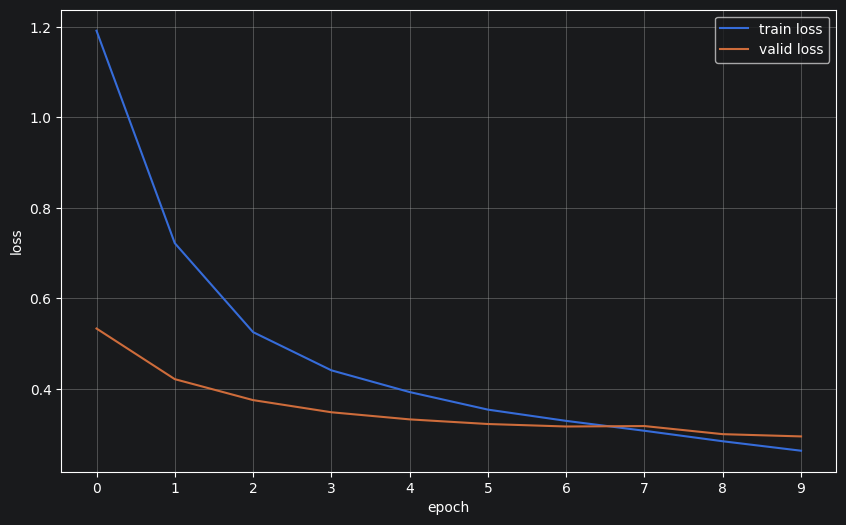

In [92]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(metrics['train_loss'], label='train loss')
ax.plot(metrics['valid_loss'], label='valid loss')
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax.set_xticks(range(n_epochs))
ax.legend()
ax.grid()

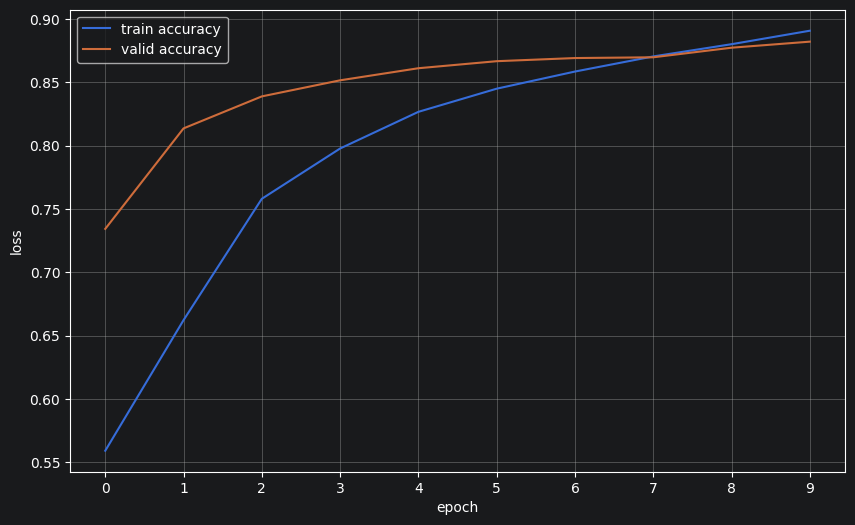

In [94]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(metrics["train_acc"], label="train accuracy")
ax.plot(metrics["valid_acc"], label="valid accuracy")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_xticks(range(n_epochs))
ax.legend()
ax.grid()

In [95]:
model.load_state_dict(torch.load('./best_model/cnn.pt'))
test_loss, test_acc = evaluate(test_data_loader, model, criterion, device)

evaluating...: 100%|██████████| 49/49 [00:18<00:00,  2.61it/s]


In [96]:
print(f'test_loss: {test_loss:.3f}, test_acc: {test_acc:.3f}')

test_loss: 0.308, test_acc: 0.870


In [99]:
def predict_sentiment(text, model, tokenizer, vocab, min_length, device, pad_index):
    tokens = tokenizer(text)
    ids = vocab.lookup_indices(tokens)
    if len(ids) < min_length:
        ids += [pad_index] * (min_length - len(ids))
    tensor = torch.LongTensor(ids).unsqueeze(dim=0).to(device)
    prediction = model(tensor).squeeze(dim=0)
    probability = torch.softmax(prediction, dim=-1)
    predicted_class = probability.argmax(dim=-1).item()
    predicted_probability = probability[predicted_class].item()
    return predicted_class, predicted_probability

In [100]:
text = 'i feel boring'
min_length = max(filter_sizes)

predict_sentiment(text, model, tokenizer, vocab, min_length, device, pad_index)

(0, 0.8632022142410278)